<center>

## Fitting and Alignment

</center>

In [12]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import random
import os

In [13]:
# Create output folder
os.makedirs('results', exist_ok=True)

---
### Question 1 – Line Fitting with Total Least Squares and RANSAC

#### 1(a) – Total Least Squares on Line 1

TLS Line 1 parameters:
  a = 0.773562
  b = -0.633721
  c = -3.794192
  Equation: 0.7736·x + -0.6337·y + -3.7942 = 0
  Slope-intercept form: y = 1.2207·x + -5.9872


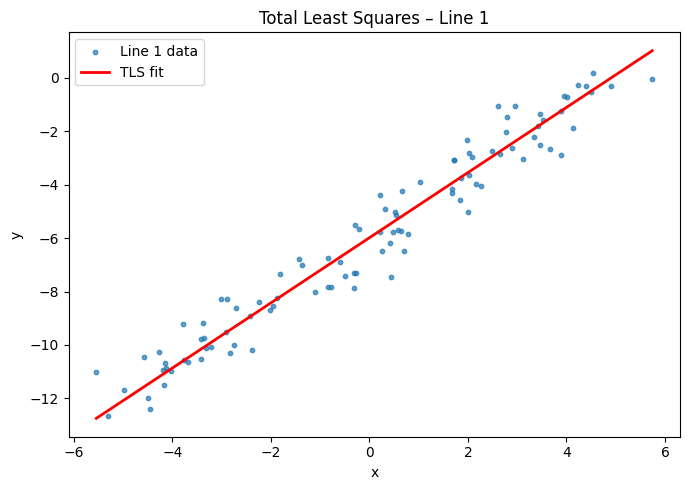

In [14]:
# Load dataset
D = np.genfromtxt('lines.csv', delimiter=',', skip_header=1)

# Extract columns for line 1 (x1, y1)
x1 = D[:, 0]
y1 = D[:, 3]

def total_least_squares(x, y):
    """
    Fit a line using Total Least Squares (TLS).
    Returns (a, b, c) such that ax + by + c = 0, normalized so that a^2 + b^2 = 1.
    """
    n = len(x)
    # Center the data
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_c = x - x_mean
    y_c = y - y_mean

    # Build data matrix
    A = np.column_stack([x_c, y_c])

    # SVD – the normal to the line is the last right singular vector
    U, S, Vt = np.linalg.svd(A)
    a, b = Vt[-1]          # normal vector (a, b)

    # c from passing through centroid: a*x_mean + b*y_mean + c = 0
    c = -(a * x_mean + b * y_mean)
    return a, b, c

a, b, c = total_least_squares(x1, y1)
print(f"TLS Line 1 parameters:")
print(f"  a = {a:.6f}")
print(f"  b = {b:.6f}")
print(f"  c = {c:.6f}")
print(f"  Equation: {a:.4f}·x + {b:.4f}·y + {c:.4f} = 0")

# Slope-intercept form (if b != 0): y = -(a/b)x - (c/b)
slope = -a / b
intercept = -c / b
print(f"  Slope-intercept form: y = {slope:.4f}·x + {intercept:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x1, y1, s=10, label='Line 1 data', alpha=0.7)
x_plot = np.linspace(x1.min(), x1.max(), 200)
y_plot = slope * x_plot + intercept
ax.plot(x_plot, y_plot, 'r-', lw=2, label='TLS fit')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Total Least Squares – Line 1')
ax.legend(); plt.tight_layout()
plt.savefig('results/Q1_tls_line1.png', dpi=120)
plt.show()

#### 1(b) – RANSAC to Fit Three Lines

Line 1: a=-0.43982, b=-0.89809, c=1.93029  | slope=-0.4897, intercept=2.1493  | inliers=71
Line 2: a=0.71335, b=-0.70080, c=0.72508  | slope=1.0179, intercept=1.0346  | inliers=58
Line 3: a=0.77700, b=-0.62950, c=-3.58780  | slope=1.2343, intercept=-5.6994  | inliers=53


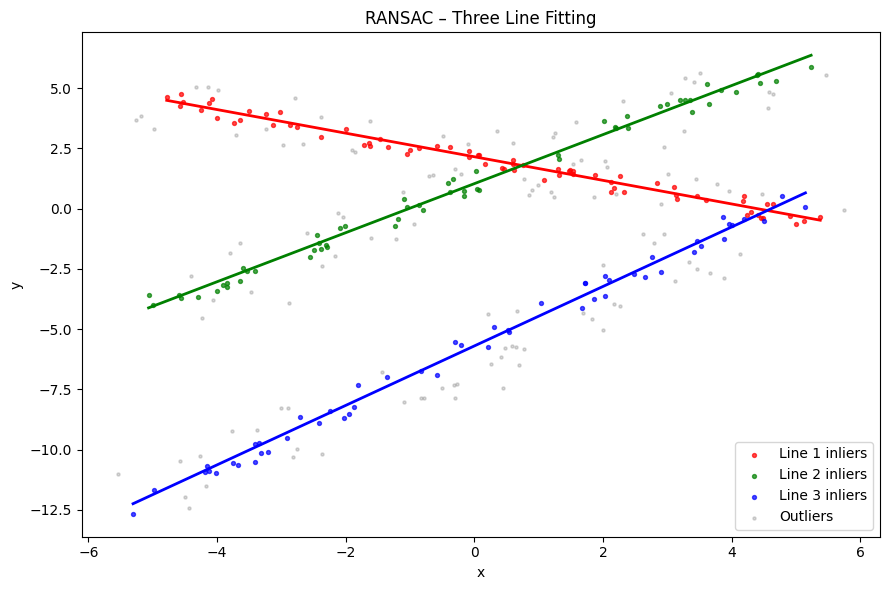

In [15]:
# Flatten all x and y columns into a single point cloud
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

points = np.column_stack([X_all, Y_all])

def point_to_line_dist(a, b, c, px, py):
    """Perpendicular distance from point (px,py) to line ax+by+c=0."""
    return np.abs(a * px + b * py + c) / np.sqrt(a**2 + b**2)

def ransac_line(pts, n_iter=1000, threshold=0.5, min_inliers=20):
    """
    RANSAC line fitting using TLS on inliers.
    Returns (a, b, c, inlier_mask).
    """
    best_inliers = []
    best_params = None
    n = len(pts)

    for _ in range(n_iter):
        # Sample 2 random points
        idx = random.sample(range(n), 2)
        p1, p2 = pts[idx[0]], pts[idx[1]]

        # Direction vector → normal
        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]
        if abs(dx) < 1e-10 and abs(dy) < 1e-10:
            continue
        a, b = dy, -dx  # normal to direction
        norm = np.sqrt(a**2 + b**2)
        a, b = a / norm, b / norm
        c = -(a * p1[0] + b * p1[1])

        dists = point_to_line_dist(a, b, c, pts[:, 0], pts[:, 1])
        inliers = np.where(dists < threshold)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_params = (a, b, c)

    # Refit with TLS on best inliers
    if best_params is not None and len(best_inliers) >= min_inliers:
        ix = pts[best_inliers, 0]
        iy = pts[best_inliers, 1]
        a, b, c = total_least_squares(ix, iy)
        dists = point_to_line_dist(a, b, c, pts[:, 0], pts[:, 1])
        mask = dists < threshold
        return a, b, c, mask
    return None

# Find 3 lines iteratively
remaining = np.ones(len(points), dtype=bool)
lines = []
colors = ['red', 'green', 'blue']

fig, ax = plt.subplots(figsize=(9, 6))

for i in range(3):
    pts_remaining = points[remaining]
    result = ransac_line(pts_remaining, n_iter=2000, threshold=0.4)
    if result is None:
        print(f"Line {i+1}: RANSAC failed.")
        break
    a, b, c, local_mask = result

    # Map local mask back to global index
    global_indices = np.where(remaining)[0]
    inlier_global = global_indices[local_mask]
    outlier_global = global_indices[~local_mask]

    lines.append((a, b, c, inlier_global))
    print(f"Line {i+1}: a={a:.5f}, b={b:.5f}, c={c:.5f}  "
          f"| slope={-a/b:.4f}, intercept={-c/b:.4f}  "
          f"| inliers={len(inlier_global)}")

    # Plot inliers
    ax.scatter(points[inlier_global, 0], points[inlier_global, 1],
               s=8, color=colors[i], alpha=0.7, label=f'Line {i+1} inliers')

    # Plot fitted line
    x_range = points[inlier_global, 0]
    x_plot = np.linspace(x_range.min(), x_range.max(), 200)
    y_plot = (-a / b) * x_plot + (-c / b)
    ax.plot(x_plot, y_plot, color=colors[i], lw=2)

    # Mask out inliers for next iteration
    remaining[inlier_global] = False

# Plot remaining outliers
if remaining.any():
    ax.scatter(points[remaining, 0], points[remaining, 1],
               s=5, c='gray', alpha=0.3, label='Outliers')

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('RANSAC – Three Line Fitting')
ax.legend(); plt.tight_layout()
plt.savefig('results/Q1_ransac_three_lines.png', dpi=120)
plt.show()

---
### Question 2 – Earring Size Estimation

Focal length in pixels: 3636.36 px
Earring image size: 1024 x 1024 px
Earring 1: bounding box = 365 x 394 px, estimated diameter = 78.01 mm
Earring 2: bounding box = 358 x 394 px, estimated diameter = 78.01 mm


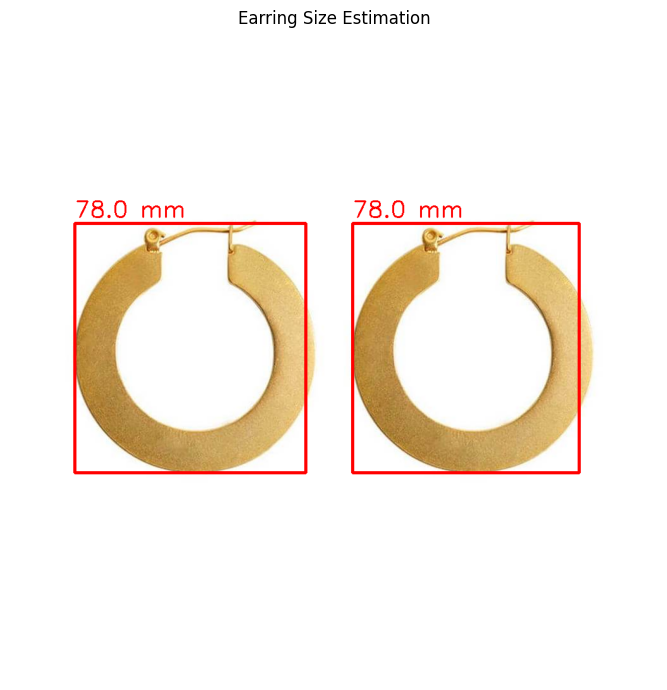


Camera model: X_world = (x_px * pixel_size * Z) / f
  pixel_size = 0.0022 mm, Z = 720.0 mm, f = 8.0 mm


In [16]:
# Camera parameters
f_mm        = 8.0          # focal length in mm
pixel_um    = 2.2          # pixel size in micrometers
pixel_mm    = pixel_um / 1000.0  # convert to mm
Z_mm        = 720.0        # object distance (lens to imaging plane) in mm

# Focal length in pixels
f_px = f_mm / pixel_mm
print(f"Focal length in pixels: {f_px:.2f} px")

# Load earring image and measure size in pixels
img_e = cv.imread('earrings.jpg')
img_e_rgb = cv.cvtColor(img_e, cv.COLOR_BGR2RGB)
H_e, W_e = img_e.shape[:2]
print(f"Earring image size: {W_e} x {H_e} px")

# Convert to grayscale and threshold to find earring region
gray_e = cv.cvtColor(img_e, cv.COLOR_BGR2GRAY)
_, thresh = cv.threshold(gray_e, 200, 255, cv.THRESH_BINARY_INV)
contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Sort contours by area (largest = earrings)
contours = sorted(contours, key=cv.contourArea, reverse=True)[:2]

img_annotated = img_e_rgb.copy()
earring_sizes_mm = []

for i, cnt in enumerate(contours):
    x, y, w, h = cv.boundingRect(cnt)
    diameter_px = max(w, h)  # largest bounding dimension

    # Real-world size: X_world = x_pixels * pixel_mm * Z_mm / f_mm
    diameter_mm = diameter_px * pixel_mm * Z_mm / f_mm
    earring_sizes_mm.append(diameter_mm)

    cv.rectangle(img_annotated, (x, y), (x + w, y + h), (255, 0, 0), 3)
    label = f'{diameter_mm:.1f} mm'
    cv.putText(img_annotated, label, (x, y - 10),
               cv.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 2)
    print(f"Earring {i+1}: bounding box = {w} x {h} px, "
          f"estimated diameter = {diameter_mm:.2f} mm")

plt.figure(figsize=(8, 7))
plt.imshow(img_annotated)
plt.title('Earring Size Estimation')
plt.axis('off')
plt.tight_layout()
plt.savefig('results/Q2_earring_size.png', dpi=120)
plt.show()

print(f"\nCamera model: X_world = (x_px * pixel_size * Z) / f")
print(f"  pixel_size = {pixel_mm} mm, Z = {Z_mm} mm, f = {f_mm} mm")

---
### Question 3 – Homography & Circuit Board Comparison

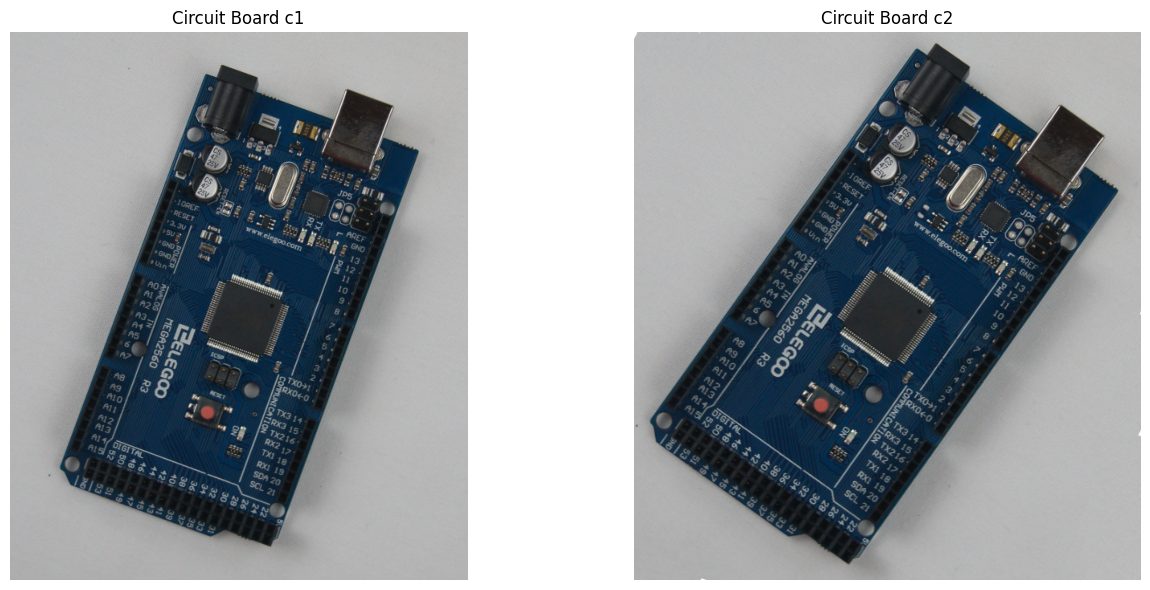

c1 size: (683, 570), c2 size: (626, 579)


In [17]:
# Load images (reduced for display)
im1 = cv.imread('c1.jpg', cv.IMREAD_REDUCED_COLOR_4)
im2 = cv.imread('c2.jpg', cv.IMREAD_REDUCED_COLOR_4)
im1_rgb = cv.cvtColor(im1, cv.COLOR_BGR2RGB)
im2_rgb = cv.cvtColor(im2, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(im1_rgb); axes[0].set_title('Circuit Board c1'); axes[0].axis('off')
axes[1].imshow(im2_rgb); axes[1].set_title('Circuit Board c2'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('results/Q3_circuit_boards.png', dpi=100)
plt.show()
print(f"c1 size: {im1.shape[:2]}, c2 size: {im2.shape[:2]}")

#### 3(a) – Manual Point Selection & Homography Warp

Homography matrix H (manual):
[[ 9.72849437e-01 -3.36247588e-02  1.31413372e+01]
 [ 6.93583296e-03  9.82166107e-01  9.45164211e+00]
 [ 2.11507131e-05 -8.78298245e-05  1.00000000e+00]]


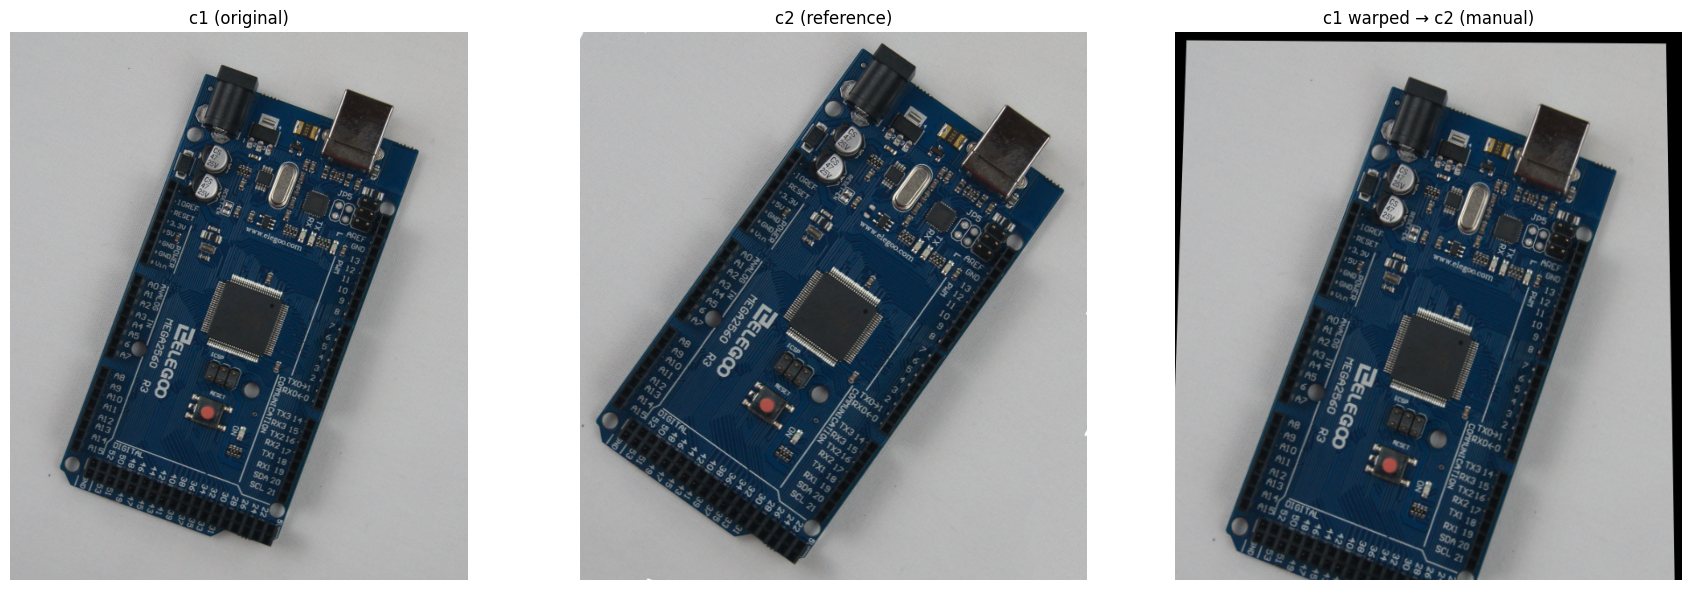

In [20]:
p1_manual = np.array([
        [120,  20],   # top-left near power jack
        [215,  20],   # top-right USB region
        [230, 105],   # large IC top-right
        [145, 165],   # large IC bottom
        [ 55, 205],   # analog pin area
        [100, 240],   # reset button
    ], dtype=np.float32)

p2_manual = np.array([
        [130,  30],
        [220,  30],
        [235, 115],
        [150, 175],
        [ 60, 215],
        [105, 250],
    ], dtype=np.float32)

# Compute homography (c1 → c2) using manual correspondences
H_manual, mask_manual = cv.findHomography(p1_manual, p2_manual, 0)
print("Homography matrix H (manual):")
print(H_manual)

# Warp c1 to the perspective of c2
h2, w2 = im2.shape[:2]
im1_warped_manual = cv.warpPerspective(im1, H_manual, (w2, h2))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv.cvtColor(im1, cv.COLOR_BGR2RGB));  axes[0].set_title('c1 (original)');   axes[0].axis('off')
axes[1].imshow(cv.cvtColor(im2, cv.COLOR_BGR2RGB));  axes[1].set_title('c2 (reference)');   axes[1].axis('off')
axes[2].imshow(cv.cvtColor(im1_warped_manual, cv.COLOR_BGR2RGB)); axes[2].set_title('c1 warped → c2 (manual)'); axes[2].axis('off')
plt.tight_layout()
plt.savefig('results/Q3_warped_manual.png', dpi=100)
plt.show()

#### 3(b) – Difference Image (Manual Homography)